In [2]:
# imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

import pc.data_gen.data_generator as dgen
from pc.plot_gen.multi_cat import MultiCatPCPGenerator
from pc.plot_gen.single_cat import SingleCatPCPGenerator
from pc.plot_gen.axes_crop import CroppingProcessor
from pc.plot_gen.line_data import LineCoordinateExtractor
from pc.plot_gen.cat_sep import CategorySeparator


# paths

#synthetic csvs
data_path = "data/raw_synthetic/training/data_example"
raw_data_path = os.path.join(project_root, data_path)

#synthetic plots multi categories 
plot_paths = "data/synthetic_plots/training/multi_plot_example"
plot_paths = os.path.join(project_root, plot_paths)

#synthetic plots single category 
splot_paths = "data/synthetic_plots/training/single_plot_example"
splot_paths = os.path.join(project_root, splot_paths)

crop_paths = os.path.join(project_root, "data/synthetic_plots/training/m_crops")
color_sep_paths = os.path.join(project_root, "data/synthetic_plots/training/color_sep")

#json_categroy_sep
all_data_sep = os.path.join(project_root, "data/synthetic_plots/training/color_sep/all_histdata.json")

In [4]:
# visualization method 

import os
import matplotlib.pyplot as plt
from PIL import Image
import io

try:
    import cairosvg
except ImportError:
    raise ImportError("Please install cairosvg with: pip install cairosvg")


def show_images_from_folder(folder_path, title="Images", max_images=4, sort=True):
    image_paths = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".svg"))
    ]

    if sort:
        image_paths.sort()

    image_paths = image_paths[:max_images]

    if not image_paths:
        print("No images found in", folder_path)
        return

    cols = 3
    rows = (len(image_paths) + cols - 1) // cols
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, path in enumerate(image_paths):
        ext = os.path.splitext(path)[1].lower()

        if ext == ".svg":
            # Convert SVG to PNG using cairosvg and load via PIL
            try:
                png_data = cairosvg.svg2png(url=path)
                img = Image.open(io.BytesIO(png_data))
            except Exception as e:
                print(f"Error loading SVG: {path}", e)
                continue
        else:
            img = Image.open(path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.basename(path))

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


### Data generation 

In [3]:
dgen.generate_synthetic_datasets(raw_data_path, 20, 'annotations.json', seed=42)

Saved annotations to: /home/poonam/myworkspace/PaCoNet/data/raw_synthetic/training/data_example/annotations.json


### Plots creation using synthetic data

In [ ]:
# mcat = MultiCatPCPGenerator()
mcat = MultiCatPCPGenerator(show_labels=False)
mcat.generate_batch(raw_data_path, plot_paths, 5)
show_images_from_folder(plot_paths, title="multi_cat")

In [ ]:
scat = SingleCatPCPGenerator(show_labels=False)
scat.generate_batch(raw_data_path, splot_paths, 5)
show_images_from_folder(splot_paths, title="single_cat")

### cropping 

In [ ]:
cp = CroppingProcessor()
cp.create_crops(plot_paths, crop_paths)
show_images_from_folder(crop_paths, title="crops")

### line data extraction 

In [2]:
extractor = LineCoordinateExtractor(plot_paths)
extractor.extract_all()
line_json = extractor.output_file

### Category separation from crops 

 Saved masks → /home/poonam/myworkspace/PaCoNet/data/synthetic_plots/training/color_sep/all_histdata.json
Saved colors → /home/poonam/myworkspace/PaCoNet/data/synthetic_plots/training/color_sep/color.json


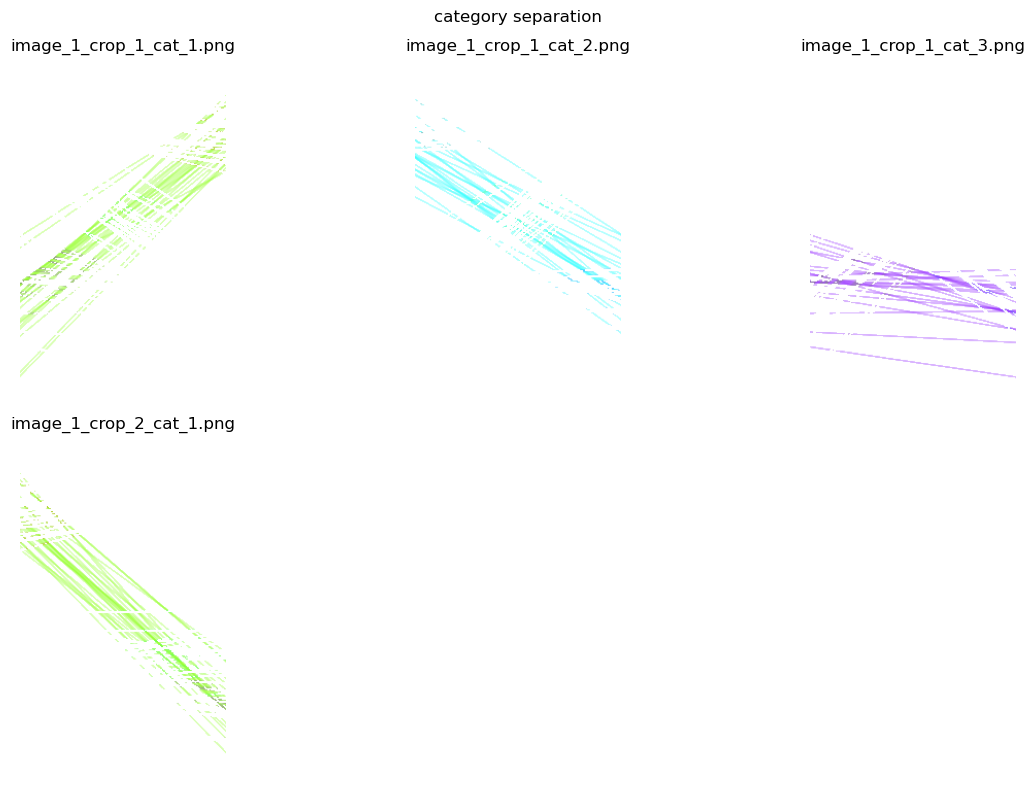

In [5]:
sep = CategorySeparator(crop_paths, line_json)  # No JSON path given

sep.separate_by_hist_peaks(output_dir=color_sep_paths)

show_images_from_folder(color_sep_paths, title="category separation")

In [ ]:
# Example usage
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1]
])


In [ ]:
import custom_dataset_unet as cus
dataset = cus.CustomHSVMatchingDatasetSDMask(
    input_json = "dataset/training_data/data04_color_thres/line_with_sepimg.json", #cls_line_json_path 
    ground_truth_json= "dataset/training_data/data04_gt_plots_crops/gt_line_color.json",
    input_dir="dataset/training_data/data04_cluster_thres",
    ground_truth_dir="dataset/training_data/data04_gt_plots_crops",
    mask_dir="dataset/training_data/data04_gt_plots_crops_masks",
    transform=transform,
    hsv_tolerance=0.1  # Adjust as needed
)

In [ ]:
# unet inference 


tester = UNetTester(config, test_config)

# Run just one test (color)
tester.run(
    input_dir=test_config.m_color_sep_plots,
    output_dir=test_config.m_color_denoised_plots,
    description="Multi-color separation"
)